In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set();

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_validate

# Отбор признаков

In [103]:
df = pd.read_csv("https://raw.githubusercontent.com/katarina74/ml_lessons/main/lesson_2/data/techparams_train.csv")
X = df.drop(["target", "index"], axis=1)
y = df[["target"]]

In [104]:
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.33, random_state=42)

## Корреляционный анализ

In [105]:
train_X.columns

Index(['back-suspension', 'battery-capacity', 'charge-time', 'compression',
       'consumption-mixed', 'cylinders-order', 'cylinders-value',
       'engine-feeding', 'engine-start', 'engine-stop', 'engine-type',
       'gear-type', 'luxury', 'max-speed', 'power-electro-kw', 'supply-system',
       'valves', 'valvetrain', 'weight', 'configurations_auto-premiere',
       'configurations_back-wheel-base', 'configurations_front-brake',
       'configurations_safety-rating', 'configurations_seats',
       'configurations_tank-volume', 'supergen_year-stop',
       'models_country-from', 'models_group', 'models_light-and-commercial',
       'models_male'],
      dtype='object')

In [106]:
ordinal = ['back-suspension', 'cylinders-order', 'engine-feeding', 'configurations_seats']
numerical = ['battery-capacity', 'charge-time', 'compression', 'consumption-mixed', 'cylinders-value', 'engine-start', 'engine-stop', 'luxury',
             'max-speed', 'power-electro-kw','valves','weight','configurations_auto-premiere','configurations_back-wheel-base','configurations_tank-volume',
             'supergen_year-stop',]
catigorial = ['engine-type','gear-type', 'supply-system', 'valvetrain', 'configurations_front-brake', 'configurations_safety-rating','models_country-from',
              'models_group', 'models_light-and-commercial','models_male']

<Axes: xlabel='engine-type', ylabel='Count'>

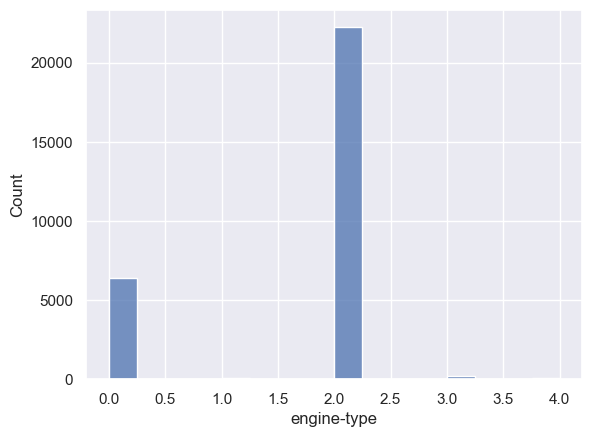

In [107]:
sns.histplot(data=train_X, x='engine-type')

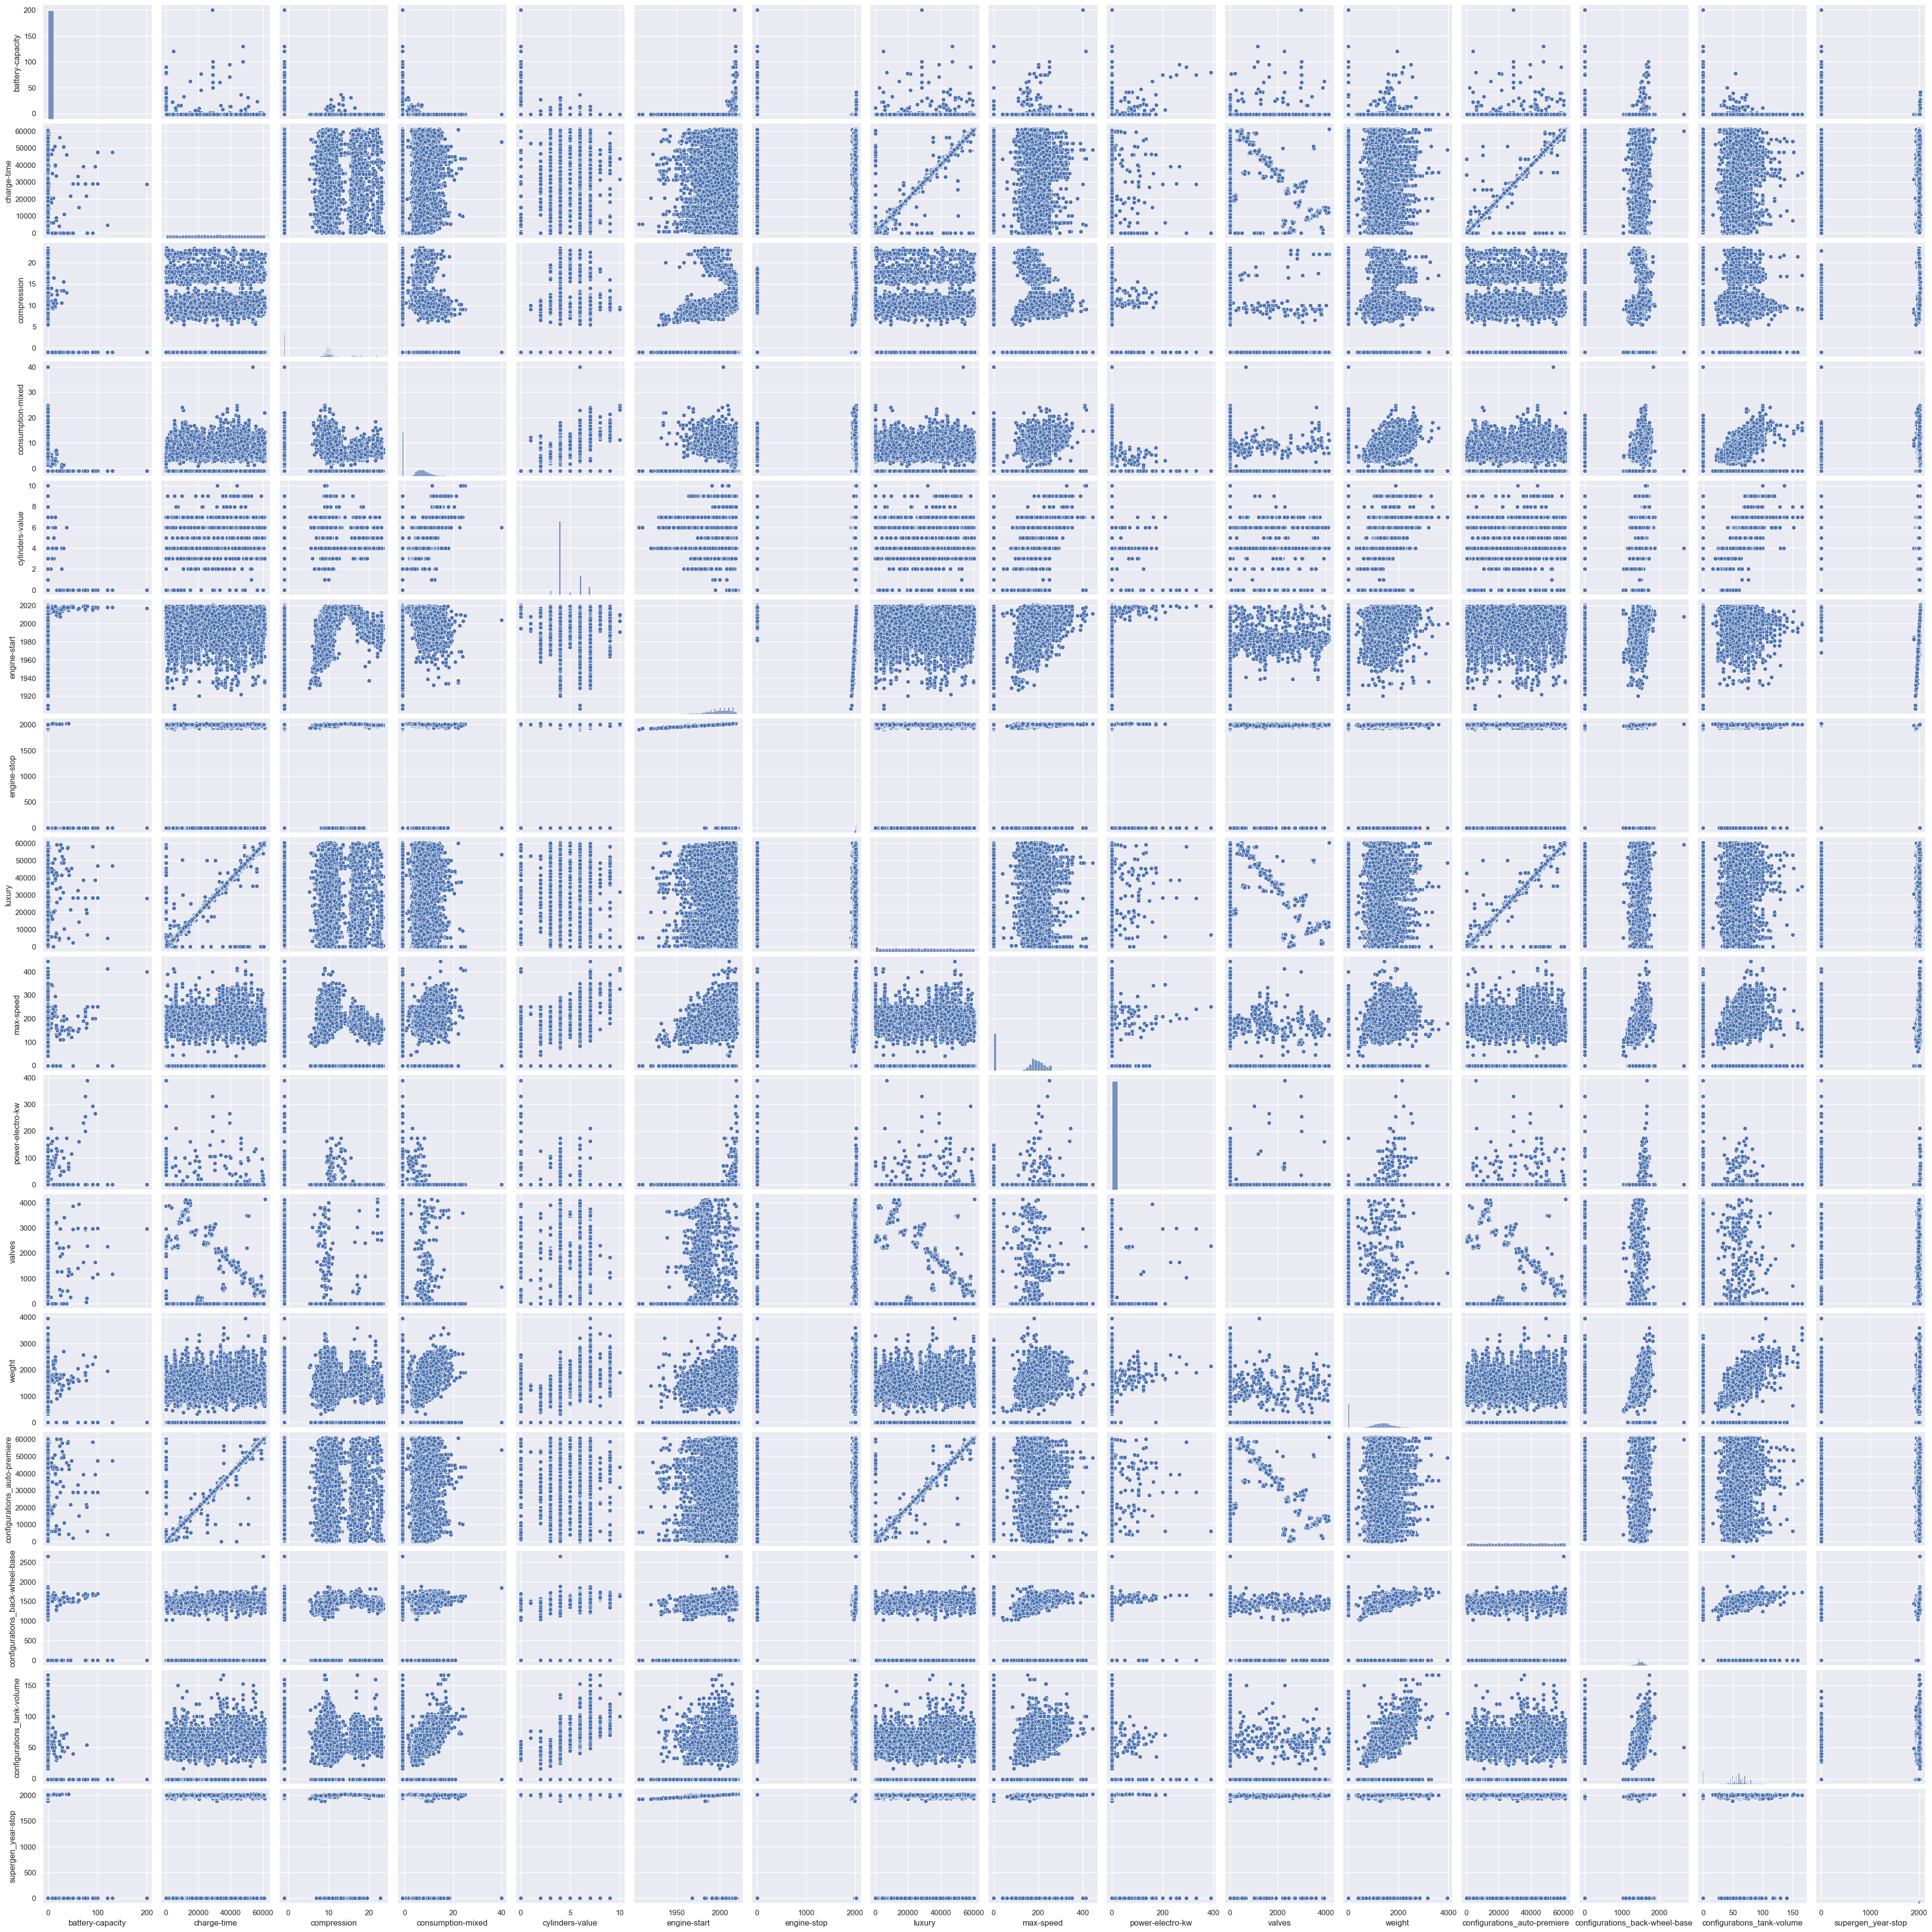

In [39]:
sns.pairplot(train_X[numerical]);

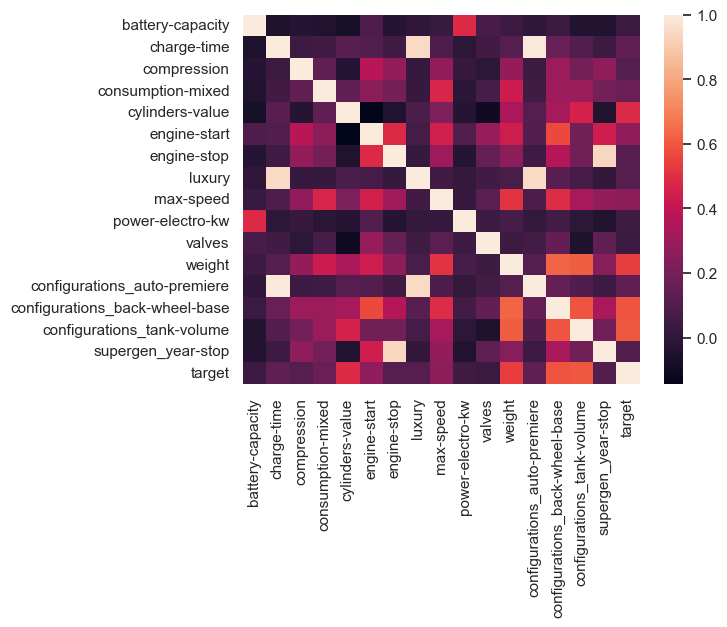

In [108]:
train = train_X
train['target'] = train_y
sns.heatmap(train[numerical + ['target']].corr(method='spearman'));

In [109]:
from scipy.stats import pearsonr, spearmanr

r = pearsonr(train['configurations_auto-premiere'], train['target'])
print('Pearson correlation:', r[0], 'p-value:', r[1])

Pearson correlation: 0.11003752360955567 p-value: 9.725646829197532e-79


In [110]:
r = pearsonr(train['battery-capacity'], train['target'])
print('Pearson correlation:', r[0], 'p-value:', r[1])

Pearson correlation: 0.023665183667100763 p-value: 5.610547363580777e-05


## F-test

In [111]:
from sklearn.feature_selection import f_regression, SelectKBest

In [112]:
f_statistic, p_values = f_regression(train_X, train_y)

C:\Users\mirwo\anaconda3\lib\site-packages\sklearn\utils\validation.py:1141: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [113]:
p_values

array([4.14261514e-178, 5.61054736e-005, 2.22583374e-084, 4.29215233e-006,
       5.19880608e-097, 0.00000000e+000, 0.00000000e+000, 3.00761649e-002,
       1.23407205e-153, 1.91780781e-122, 1.08128701e-102, 5.89170255e-038,
       1.18423856e-051, 6.73034264e-090, 6.04804785e-008, 3.29025321e-015,
       3.33873440e-033, 1.45689423e-002, 0.00000000e+000, 9.72564683e-079,
       6.46321123e-022, 5.15233301e-231, 8.63015515e-002, 0.00000000e+000,
       0.00000000e+000, 1.90641086e-122, 7.01981268e-140, 5.09638729e-005,
       4.56879391e-064, 3.51507643e-001, 0.00000000e+000])

In [114]:
sekector = SelectKBest(f_regression, k=20)
sekector.fit_transform(train_X, train_y)

C:\Users\mirwo\anaconda3\lib\site-packages\sklearn\utils\validation.py:1141: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([[ 3.0000e+00,  1.1636e+04, -1.0000e+00, ...,  1.6000e+01,
         0.0000e+00,  2.4300e+03],
       [ 8.0000e+00,  3.1764e+04, -1.0000e+00, ...,  2.3000e+01,
         0.0000e+00,  2.4400e+03],
       [ 8.0000e+00,  2.7730e+03,  6.8000e+00, ...,  1.0000e+01,
         0.0000e+00,  2.6850e+03],
       ...,
       [ 3.0000e+00,  4.8819e+04,  7.6000e+00, ...,  2.6000e+01,
         0.0000e+00,  2.6700e+03],
       [ 1.0000e+01,  9.3460e+03, -1.0000e+00, ...,  1.6000e+01,
         0.0000e+00,  2.5000e+03],
       [ 3.0000e+00,  4.3309e+04, -1.0000e+00, ...,  3.5000e+01,
         0.0000e+00,  2.8800e+03]])

In [115]:
sekector.get_feature_names_out()

array(['back-suspension', 'charge-time', 'consumption-mixed',
       'cylinders-order', 'cylinders-value', 'engine-start',
       'engine-stop', 'engine-type', 'gear-type', 'luxury', 'max-speed',
       'weight', 'configurations_auto-premiere',
       'configurations_front-brake', 'configurations_seats',
       'configurations_tank-volume', 'supergen_year-stop',
       'models_country-from', 'models_light-and-commercial', 'target'],
      dtype=object)

## Значения Шепли

In [116]:
import shap

In [117]:
!pip install shap

In [118]:
reg = LinearRegression().fit(train_X, train_y)

In [119]:
explainer = shap.Explainer(reg, train_X)
shap_values = explainer(train_X)

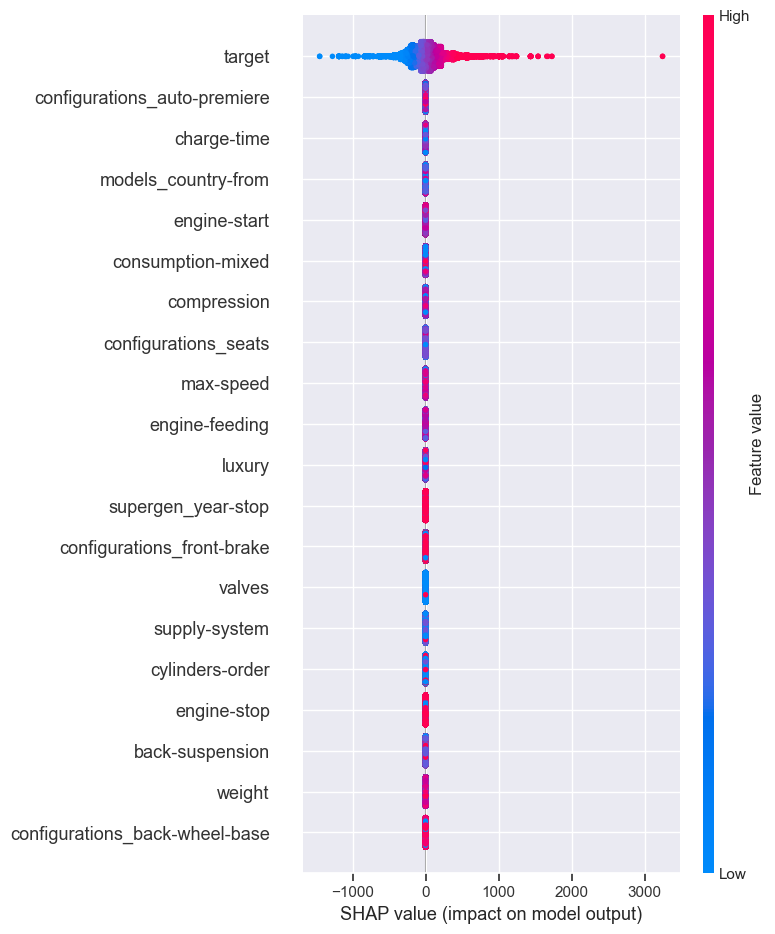

In [120]:
shap.summary_plot(shap_values, train_X)

Для признака cylinders-value наблюдается положительная статистическая зависимость от целевой переменной. Сравните Ваш результат с результатом работы библиотеки shap.

In [121]:
train_cut_X = train_X[train_X.columns[:5]]
test_cut_X = test_X[train_X.columns[:5]]

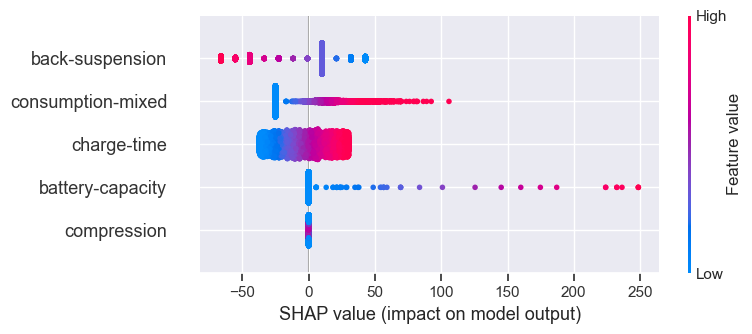

In [122]:
reg = LinearRegression().fit(train_cut_X, train_y)

explainer = shap.Explainer(reg, train_cut_X)
shap_values = explainer(test_cut_X)

shap.summary_plot(shap_values, test_cut_X)

### Задание

Для сокращенных данных (train_cut_X и test_cut_X) реализовать метод отбора важности признаков по Шепли.

## Пермутационная важность

In [123]:
#from eli5 import show_weights
from eli5.sklearn import PermutationImportance

In [124]:
!pip install eli5

In [125]:
!pip uninstall scikit-learn -y

Found existing installation: scikit-learn 1.2.0
Uninstalling scikit-learn-1.2.0:
  Successfully uninstalled scikit-learn-1.2.0


In [126]:
!pip install scikit-learn==1.2.0

  Using cached scikit_learn-1.2.0-cp310-cp310-win_amd64.whl (8.2 MB)


In [127]:
reg = LinearRegression().fit(train_X, train_y)

In [128]:
perm = PermutationImportance(reg, random_state=42).fit(test_X, test_y)

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- target


In [ ]:
eli5.show_weights(perm, feature_names=list(test_X.columns))

### Задание

Самостоятельно реализовать алгоритм отбора признаков на основе пермутационной важности. Построить гистограмму полученных значений.

In [ ]:
import statsmodels.api as sm

In [ ]:
reg_sm = sm.OLS(train_y, train_X).fit()

In [ ]:
def importance(dataframe, column_name):
    X = dataframe.drop(["target", "index", column_name], axis=1)
    y = dataframe[["target"]]
    train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.33, random_state=42)
    model_return = sm.OLS(train_y, train_X).fit()
    #pvalues = pd.DataFrame(model_return.pvalues.sort_values()).reset_index()
    return (model_return)

In [ ]:
max(reg_sm.pvalues)

In [ ]:
pvalues = pd.DataFrame(reg_sm.pvalues.sort_values()).reset_index()
pvalues

In [ ]:
importance(df, pvalues.iloc[-1, 0])

In [ ]:
pvalues = pd.DataFrame(reg_sm.pvalues.sort_values()).reset_index(drop=True)
while max(reg_sm.pvalues) > 0.05:
    reg_sm = importance(df, pvalues.iloc[-1, 0]).model_return

pvalues

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/katarina74/ml_lessons/main/lesson_2/data/techparams_train.csv")
X = df.drop(["target", "index"], axis=1)
y = df[["target"]]

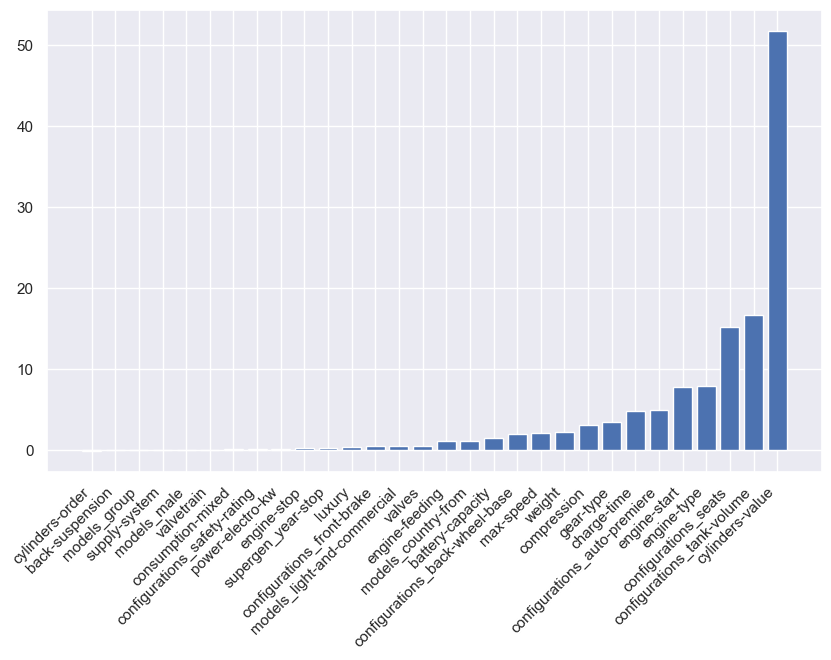

In [129]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
baseline_rmse = np.sqrt(mean_squared_error(y_test, model.predict(X_test)))
feature_importances = {}
for feature in X.columns:
    importances = []
    X_test_permuted = X_test.copy()
    X_test_permuted[feature] = np.random.permutation(X_test_permuted[feature])
    y_pred_permuted = model.predict(X_test_permuted)
    rmse_permuted = np.sqrt(mean_squared_error(y_test, y_pred_permuted))
    importance = rmse_permuted - baseline_rmse
    importances.append(importance)
    feature_importances[feature] = np.mean(importances)
sorted_feature_importances = dict(sorted(feature_importances.items(), key=lambda item: item[1]))
plt.figure(figsize=(10, 6))
plt.bar(sorted_feature_importances.keys(), sorted_feature_importances.values())
plt.xticks(rotation=45, ha="right")
plt.show()